In [1]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# División entrenamiento/prueba
from sklearn.model_selection import train_test_split

# Modelo Random Forest
from sklearn.ensemble import RandomForestRegressor

# Métricas de evaluación
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Librería para guardar modelos entrenados
import joblib

In [2]:
# ==========================================
# CARGAR DATASET LIMPIO
# ==========================================

# Ruta dataset limpio
ruta = "../data/processed/energy_dataset_clean.csv"

# Cargar dataset
df = pd.read_csv(
    
    ruta,
    
    # Convertir datetime automáticamente
    parse_dates=["Datetime"]
)

# Mostrar primeras filas
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Year,Month,Day,Hour,Weekday
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16,17,Saturday
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16,17,Saturday
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16,17,Saturday
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16,17,Saturday
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16,17,Saturday


In [3]:
# ==========================================
# SELECCIÓN DE VARIABLES
# ==========================================

# Variables de entrada
X = df[
    [
        "Global_reactive_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
]

# Variable objetivo
y = df["Global_active_power"]

# Mostrar dimensiones
print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

Dimensiones de X:
(1591650, 6)

Dimensiones de y:
(1591650,)


In [4]:
# ==========================================
# DIVISIÓN TRAIN Y TEST
# ==========================================

# Librería para dividir datos
from sklearn.model_selection import train_test_split

# Dividir dataset
X_train, X_test, y_train, y_test = train_test_split(
    
    # Variables de entrada
    X,
    
    # Variable objetivo
    y,
    
    # 20% para pruebas
    test_size=0.2,
    
    # Semilla aleatoria
    random_state=42
)

# Mostrar dimensiones
print("X_train:")
print(X_train.shape)

print("\nX_test:")
print(X_test.shape)

print("\ny_train:")
print(y_train.shape)

print("\ny_test:")
print(y_test.shape)

X_train:
(1273320, 6)

X_test:
(318330, 6)

y_train:
(1273320,)

y_test:
(318330,)


In [5]:
# ==========================================
# ENTRENAMIENTO RANDOM FOREST
# ==========================================

# Crear modelo
rf_model = RandomForestRegressor(
    
    # Cantidad de árboles
    n_estimators=50,
    
    # Semilla aleatoria
    random_state=42
)

# Entrenar modelo
rf_model.fit(
    
    # Variables entrenamiento
    X_train,
    
    # Objetivo entrenamiento
    y_train
)

# Mensaje
print("Modelo Random Forest entrenado correctamente")

Modelo Random Forest entrenado correctamente


In [6]:
# ==========================================
# PREDICCIONES RANDOM FOREST
# ==========================================

# Realizar predicciones
rf_pred = rf_model.predict(
    
    # Datos de prueba
    X_test
)

# Mostrar primeras predicciones
print("Primeras predicciones:")

print(rf_pred[:10])

Primeras predicciones:
[1.68494    1.74308    0.5852     4.20512    0.09989552 1.168956
 0.15144406 0.3788     1.51388    5.19464   ]


In [7]:
# ==========================================
# MÉTRICAS RANDOM FOREST
# ==========================================

# Calcular MAE
rf_mae = mean_absolute_error(
    
    # Valores reales
    y_test,
    
    # Predicciones
    rf_pred
)

# Calcular MSE
rf_mse = mean_squared_error(
    
    y_test,
    
    rf_pred
)

# Calcular RMSE
rf_rmse = np.sqrt(
    rf_mse
)

# Calcular R2
rf_r2 = r2_score(
    
    y_test,
    
    rf_pred
)

# Mostrar métricas
print("MAE:")
print(rf_mae)

print("\nMSE:")
print(rf_mse)

print("\nRMSE:")
print(rf_rmse)

print("\nR2:")
print(rf_r2)

MAE:
0.01846052977140482

MSE:
0.001109936586068618

RMSE:
0.0333157107993904

R2:
0.9990723419751509


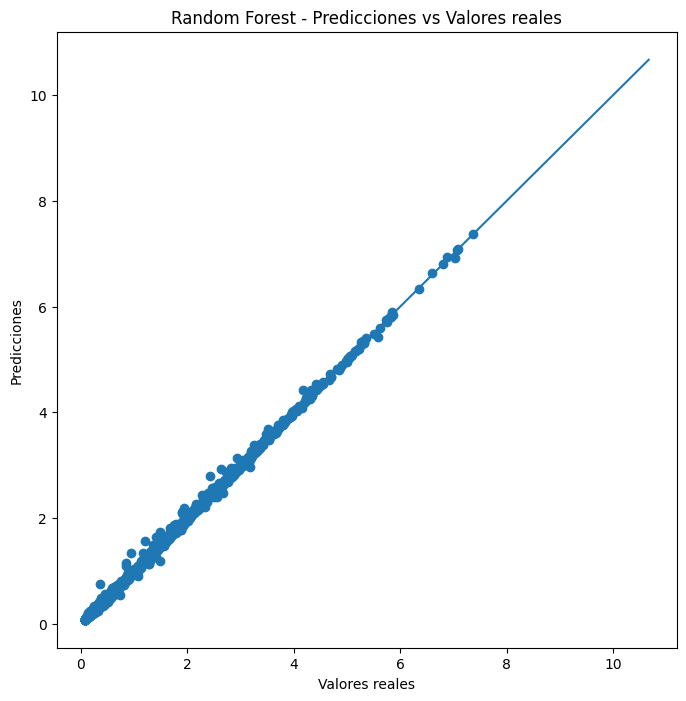

In [8]:
# ==========================================
# SCATTER PLOT RANDOM FOREST
# ==========================================

# Crear figura
plt.figure(figsize=(8,8))

# Scatter plot
plt.scatter(
    
    # Valores reales
    y_test[:3000],
    
    # Predicciones
    rf_pred[:3000]
)

# Línea ideal
plt.plot(
    
    [y_test.min(), y_test.max()],
    
    [y_test.min(), y_test.max()]
)

# Título
plt.title(
    "Random Forest - Predicciones vs Valores reales"
)

# Eje X
plt.xlabel("Valores reales")

# Eje Y
plt.ylabel("Predicciones")

# Mostrar gráfica
plt.show()

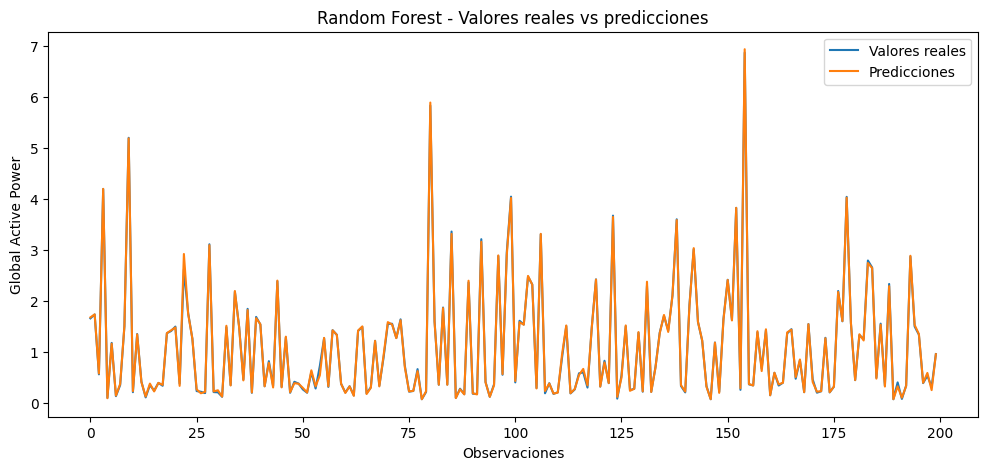

In [9]:
# ==========================================
# REAL VS PREDICCIÓN
# ==========================================

# Crear figura
plt.figure(figsize=(12,5))

# Valores reales
plt.plot(
    
    y_test.values[:200],
    
    label="Valores reales"
)

# Predicciones
plt.plot(
    
    rf_pred[:200],
    
    label="Predicciones"
)

# Título
plt.title(
    "Random Forest - Valores reales vs predicciones"
)

# Eje X
plt.xlabel("Observaciones")

# Eje Y
plt.ylabel("Global Active Power")

# Mostrar leyenda
plt.legend()

# Mostrar gráfica
plt.show()

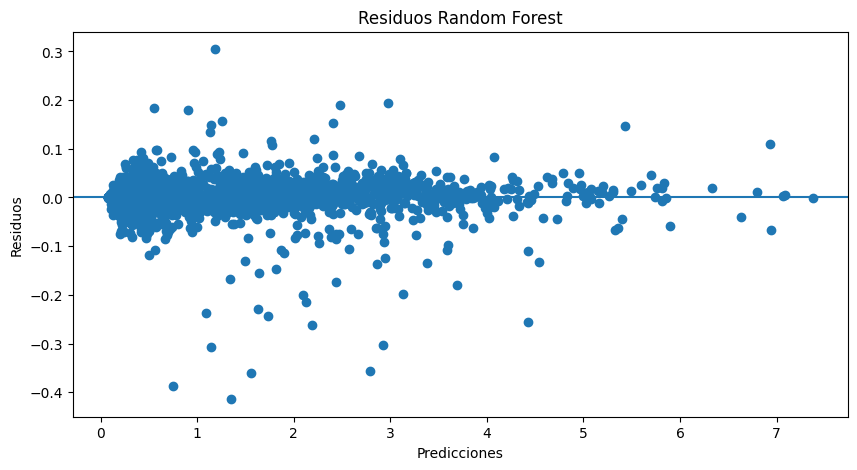

In [10]:
# ==========================================
# RESIDUOS RANDOM FOREST
# ==========================================

# Calcular residuos
rf_residuos = y_test - rf_pred

# Crear figura
plt.figure(figsize=(10,5))

# Scatter residuos
plt.scatter(
    
    rf_pred[:3000],
    
    rf_residuos[:3000]
)

# Línea horizontal ideal
plt.axhline(
    
    y=0
)

# Título
plt.title(
    "Residuos Random Forest"
)

# Eje X
plt.xlabel("Predicciones")

# Eje Y
plt.ylabel("Residuos")

# Mostrar gráfica
plt.show()

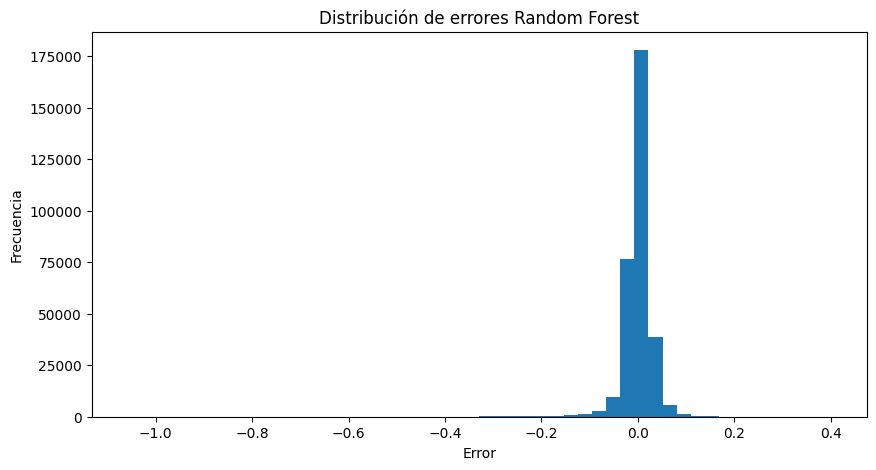

In [11]:
# ==========================================
# HISTOGRAMA DE ERRORES
# ==========================================

# Crear figura
plt.figure(figsize=(10,5))

# Histograma residuos
plt.hist(
    
    rf_residuos,
    
    bins=50
)

# Título
plt.title(
    "Distribución de errores Random Forest"
)

# Eje X
plt.xlabel("Error")

# Eje Y
plt.ylabel("Frecuencia")

# Mostrar gráfica
plt.show()

In [12]:
# ==========================================
# GUARDAR MÉTRICAS
# ==========================================

# Crear dataframe métricas
rf_metrics = pd.DataFrame({

    "Modelo": ["Random Forest"],

    "MAE": [rf_mae],

    "RMSE": [rf_rmse],

    "R2": [rf_r2]
})

# Guardar CSV
rf_metrics.to_csv(
    
    "../results/random_forest_metrics.csv",
    
    index=False
)

print("Métricas guardadas")

Métricas guardadas


In [13]:
# ==========================================
# GUARDAR MODELO RANDOM FOREST
# ==========================================

# Guardar modelo entrenado
joblib.dump(
    
    # Modelo entrenado
    rf_model,
    
    # Ruta guardado
    "../models/random_forest.pkl"
)

# Mensaje confirmación
print(
    "Modelo Random Forest guardado correctamente"
)

Modelo Random Forest guardado correctamente
